In [1]:
from pandas_plink import read_plink
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

import os
import csv
import json
import gc

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from phenotype_levels import phenotype_levels_used
from data_preparation import snp_matrix

import multiprocessing as mp
from trainer import train_single_phenotype

2026-02-19 02:27:09.344384: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-19 02:27:09.367341: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-19 02:27:09.374328: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-19 02:27:09.390999: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
def plot_benchmark(filename):
    df = pd.read_csv(filename)
    df = df.sort_values('model_acc', ascending=False)
    plt.figure(figsize=(10, len(df) * 0.3))
    sns.barplot(x='model_acc', y='phenotype', data=df, color='#2ECC71', label='Model Accuracy')
    sns.barplot(x='apriori_acc', y='phenotype', data=df, color='#A9A9A9', label='Apriori Accuracy', alpha=0.8)

    for i, row in enumerate(df.itertuples()):
        plt.text(row.model_acc + 0.01, i, f'{row.model_acc:.2%}', va='center')

    plt.title('Apriori vs model accuracy')
    plt.xlabel('Accuracy')
    plt.xlim(0, 1.1)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

In [4]:
def plot_benchmark_scatter(filename):
    df = pd.read_csv(filename)
    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=df, x='apriori_acc', y='model_acc', s=100)
    
    lims = [0, 1]
    plt.plot(lims, lims, '--r', alpha=0.75, label='hranice')

    plt.title('Apriori vs model accuracy')
    plt.xlabel('Apriory Accuracy')
    plt.ylabel('Model Test Accuracy')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

In [5]:
def get_finished_phenotypes(filename):
    if not os.path.isfile(filename):
        return []
    df = pd.read_csv(filename)
    return df["phenotype"].tolist()

In [6]:
if __name__ == "__main__":
    try:
        mp.set_start_method('spawn', force=True)
    except RuntimeError:
        pass

    fam_path = "/storage/plzen4-ntis/home/tadsova/rice_data/base_filtered_v0.7_0.8_10kb_1_0.8_50_1.fam"
    pheno_path = "phenotypes/all_phenotypes.txt"
    prefix = "/storage/plzen4-ntis/home/tadsova/rice_data/base_filtered_v0.7_0.8_10kb_1_0.8_50_1"

    X = snp_matrix(prefix)
    
    phenotypes = list(phenotype_levels_used.keys())
    results_file = "phenotype_benchmarks_2.csv"
    
    config = {
        'START_MASK': 0.5,
        'END_MASK': 0.95
    }

    for pheno_name in phenotypes:
        if pheno_name in get_finished_phenotypes(results_file):
            continue

        p = mp.Process(
            target=train_single_phenotype, 
            args=(pheno_name, X, pheno_path, fam_path, results_file, config)
        )
        
        p.start()
        p.join()
        
        print(f"Fenotyp {pheno_name} dokončen.")

Celkem chybějících genotypů: 54071435
Genotype matrix shape: (3024, 404388)


2026-02-19 02:30:44.511623: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-19 02:30:44.534788: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-19 02:30:44.542002: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Počet vzorků 'AWCO_REV' po filtraci: 2264

Distribuce hodnot pro: AWCO_REV
VALUE
0      1806
11       11
20      277
40       25
52        4
61       11
70       31
80       97
100       1
999       1
Name: count, dtype: int64
Celkem: 2264 vzorků
Apriori accuracy (majority class): 0.7977

One-hot kódování provedeno.
Tvar matice fenotypů: (2264, 9)
[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]]

Původní počet vzorků v X: 3024
Počet vzorků po filtraci: 2264
Prvních 10 vybraných indexů řádků: [571 572 573 574 575 576 585 592 617 618]
Nová velikost matice X: (2264, 404388)
Dokončené rozdělení dat
X_train: (1584, 404388), y_train: (1584, 9)
X_val:   (340, 404388),   y_val:   (340, 9)
X_test:  (340, 404388),  y_test:  (340, 9)
Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

49/49 [==============================] - 39s 735ms/step - loss: 9.2849 - categorical_accuracy: 0.1894 - val_loss: 8.4437 - val_categorical_accuracy: 0.6625 - lr: 1.0000e-06
Epoch 2/50
49/49 [==============================] - 37s 747ms/step - loss: 9.1882 - categorical_accuracy: 0.2041 - val_loss: 8.2317 - val_categorical_accuracy: 0.5906 - lr: 1.0000e-06
Epoch 3/50
49/49 [==============================] - 37s 755ms/step - loss: 8.9223 - categorical_accuracy: 0.2054 - val_loss: 8.1198 - val_categorical_accuracy: 0.5969 - lr: 1.0000e-06
Epoch 4/50
49/49 [==============================] - 37s 761ms/step - loss: 8.5984 - categorical_accuracy: 0.2130 - val_loss: 8.1072 - val_categorical_accuracy: 0.5969 - lr: 1.0000e-06
Epoch 5/50
49/49 [==============================] - 37s 751ms/step - loss: 8.5381 - categorical_accuracy: 0.2073 - val_loss: 8.0075 - val_categorical_accuracy: 0.6250 - lr: 1.0000e-06
Epoch 6/50
49/49 [==============================] - 37s 753ms/step - loss: 8.3799 - categor

...

Počet vzorků 'SECOND_BR_REPRO' po filtraci: 1522

Distribuce hodnot pro: SECOND_BR_REPRO
VALUE
1    1478
2      37
3       7
Name: count, dtype: int64
Celkem: 1522 vzorků
Apriori accuracy (majority class): 0.9711

One-hot kódování provedeno.
Tvar matice fenotypů: (1522, 4)
[[0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 ...
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]

Původní počet vzorků v X: 3024
Počet vzorků po filtraci: 1522
Prvních 10 vybraných indexů řádků: [572 574 575 617 618 627 752 756 757 758]
Nová velikost matice X: (1522, 404388)
Dokončené rozdělení dat
X_train: (1064, 404388), y_train: (1064, 4)
X_val:   (229, 404388),   y_val:   (229, 4)
X_test:  (229, 404388),  y_test:  (229, 4)
Epoch 1/50


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
''+ptx85' is not a recognized feature for this target (ignoring feature)
+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

 2/33 [>.............................] - ETA: 3s - loss: 33.0934 - categorical_accuracy: 0.1875  

Process Process-27:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/auto/plzen4-ntis/home/tadsova/trainer.py", line 194, in train_single_phenotype
    history = model.fit(
              ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tf_keras/src/utils/traceback_utils.py", line 70, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "/usr/local/lib/python3.12/dist-packages/tensorflow/python/eager/execute.py", line 59, in quick_execute
    except TypeError as e:
tensorflow.python.framework.errors_impl.InvalidArgumentError: Graph execution error:

Detected at node GatherV2 defined at (most recent call last):
<stack traces unavailable>
Detected at node GatherV2 defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  

Fenotyp SECOND_BR_REPRO dokončen.


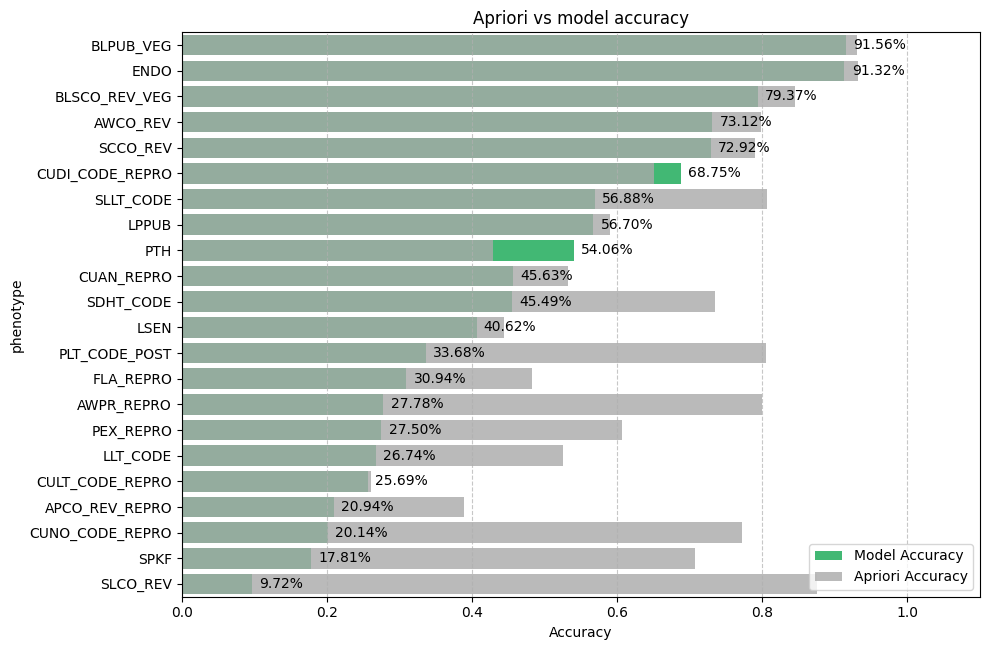

In [7]:
plot_benchmark(results_file)

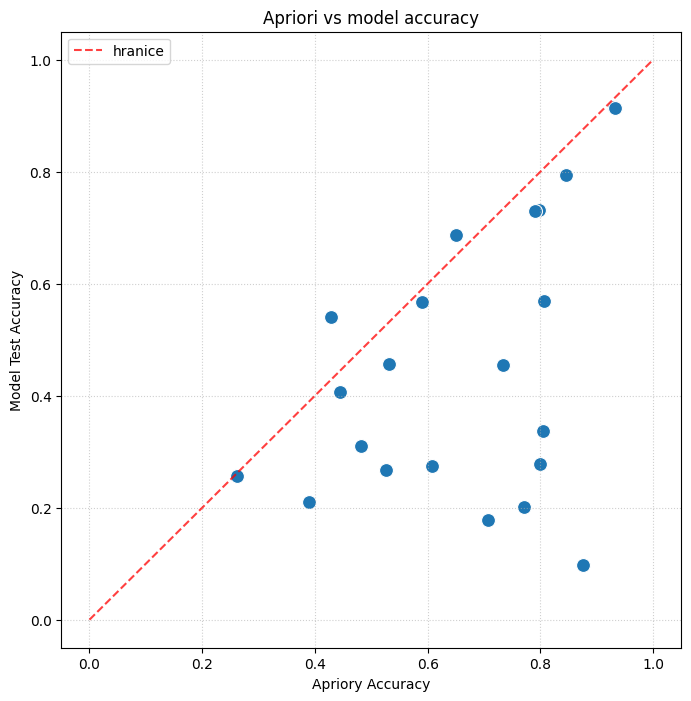

In [8]:
plot_benchmark_scatter(results_file)